# Base Unificada — Reconstrução por Retornos

Resolve a **descontinuidade na fronteira 2015/S2 → 2016/S1** entre as duas bases de preços.

## O problema

As duas bases usam `adj_close`, mas com **datas de normalização diferentes**:
- Base do professor: adj_close tal como baixado em ~dez/2015
- Extensão: adj_close tal como baixado em 2026

Um split ocorrido entre 2016 e 2025 (ex: split 4-for-1 da AAPL em ago/2020) faz o Yahoo retroativamente dividir todos os preços históricos por 4. Assim, o mesmo dia tem preços diferentes dependendo de *quando* o download foi feito. Ao concatenar as duas bases, surge um salto artificial na fronteira.

## A solução

Os **retornos diários** $r_t = P_t / P_{t-1} - 1$ são imunes a essa diferença de normalização, pois o fator de ajuste cancela. A ideia do professor é:

1. Manter os preços da base do professor intactos até 2015/S2
2. Para cada ticker na interseção, **escalar toda a série da extensão** de modo que seu primeiro valor coincida com o último preço da base do professor
3. Isso preserva todos os retornos diários intra-extensão e elimina o salto artificial

$$P_{\text{uni}}(t) = P_{\text{prof}}(t_{\text{fim}}) \cdot \frac{P_{\text{ext}}(t)}{P_{\text{ext}}(t_0)}$$

onde $t_{\text{fim}}$ é o último dia do professor e $t_0$ é o primeiro dia da extensão.

> **Esta base é independente de `base_completa.csv`** — não altera nenhum notebook existente.
> Para usá-la em `pairs_formation.ipynb`, basta trocar o arquivo de entrada.

## 1. Setup

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

META_COLS = ['year', 'semester', 'period', 'day_in_semester', 'total_days_sem']

## 2. Carregando as bases

In [18]:
prof = pd.read_csv('../../data_bases/professor_consolidado.csv', parse_dates=['date'])
ext  = pd.read_csv('../../data_bases/extensao_2016_2025.csv',   parse_dates=['date'])

prof = prof.set_index('date')
ext  = ext.set_index('date')

prof_tickers = [c for c in prof.columns if c not in META_COLS]
ext_tickers  = [c for c in ext.columns  if c not in META_COLS]

tickers_ambas    = sorted(set(prof_tickers) & set(ext_tickers))
tickers_so_prof  = sorted(set(prof_tickers) - set(ext_tickers))
tickers_so_ext   = sorted(set(ext_tickers)  - set(prof_tickers))

print(f"Professor : {len(prof_tickers):4d} tickers | {prof.index[0].date()} → {prof.index[-1].date()}")
print(f"Extensão  : {len(ext_tickers):4d} tickers | {ext.index[0].date()} → {ext.index[-1].date()}")
print()
print(f"Interseção (âncora disponível) : {len(tickers_ambas):4d}")
print(f"Só no professor (sem extensão) : {len(tickers_so_prof):4d}")
print(f"Só na extensão  (sem âncora)   : {len(tickers_so_ext):4d}")

Professor : 1100 tickers | 1990-07-03 → 2015-12-30
Extensão  :  708 tickers | 2016-01-04 → 2025-12-31

Interseção (âncora disponível) :  465
Só no professor (sem extensão) :  635
Só na extensão  (sem âncora)   :  243


## 3. Diagnóstico: dimensão do problema

Para os tickers na interseção, calculamos o **fator de escala** entre o último preço do professor e o primeiro preço da extensão. Um fator ≠ 1 indica a descontinuidade que queremos corrigir.

=== Fator de escala  prof_last / ext_first ===
Mediana  : 1.2996
Média    : 1.9210
Min      : 0.0993  (DELL)
Max      : 54.1198  (CMG)

Tickers com fator > 1.5 (splits relevantes): 123
Tickers com fator < 0.7 (dividendos/reverse): 9
Tickers com fator ≈ 1.0 (±5%): 55


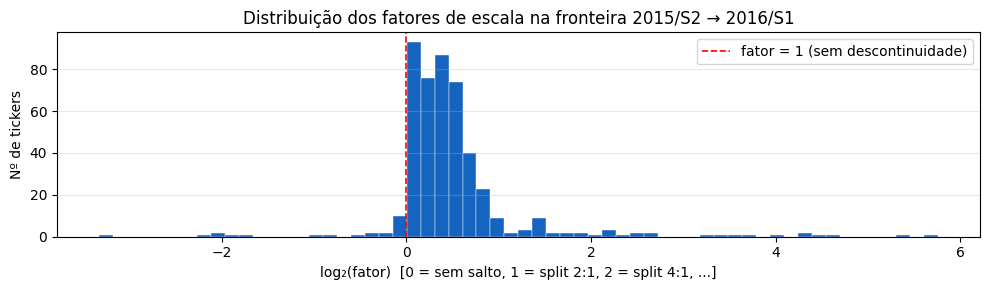

In [19]:
fatores = {}
for ticker in tickers_ambas:
    prof_valid = prof[ticker].dropna()
    ext_valid  = ext[ticker].dropna()
    if len(prof_valid) == 0 or len(ext_valid) == 0:
        continue
    fatores[ticker] = prof_valid.iloc[-1] / ext_valid.iloc[0]

fatores_s = pd.Series(fatores)

print("=== Fator de escala  prof_last / ext_first ===")
print(f"Mediana  : {fatores_s.median():.4f}")
print(f"Média    : {fatores_s.mean():.4f}")
print(f"Min      : {fatores_s.min():.4f}  ({fatores_s.idxmin()})")
print(f"Max      : {fatores_s.max():.4f}  ({fatores_s.idxmax()})")
print(f"\nTickers com fator > 1.5 (splits relevantes): {(fatores_s > 1.5).sum()}")
print(f"Tickers com fator < 0.7 (dividendos/reverse): {(fatores_s < 0.7).sum()}")
print(f"Tickers com fator ≈ 1.0 (±5%): {((fatores_s > 0.95) & (fatores_s < 1.05)).sum()}")

# Histograma dos fatores
fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(np.log2(fatores_s), bins=60, color='#1565C0', edgecolor='white', lw=0.3)
ax.axvline(0, color='red', lw=1.2, ls='--', label='fator = 1 (sem descontinuidade)')
ax.set_xlabel('log₂(fator)  [0 = sem salto, 1 = split 2:1, 2 = split 4:1, ...]')
ax.set_ylabel('Nº de tickers')
ax.set_title('Distribuição dos fatores de escala na fronteira 2015/S2 → 2016/S1')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 3.1 Exemplos do problema — salto visível na fronteira

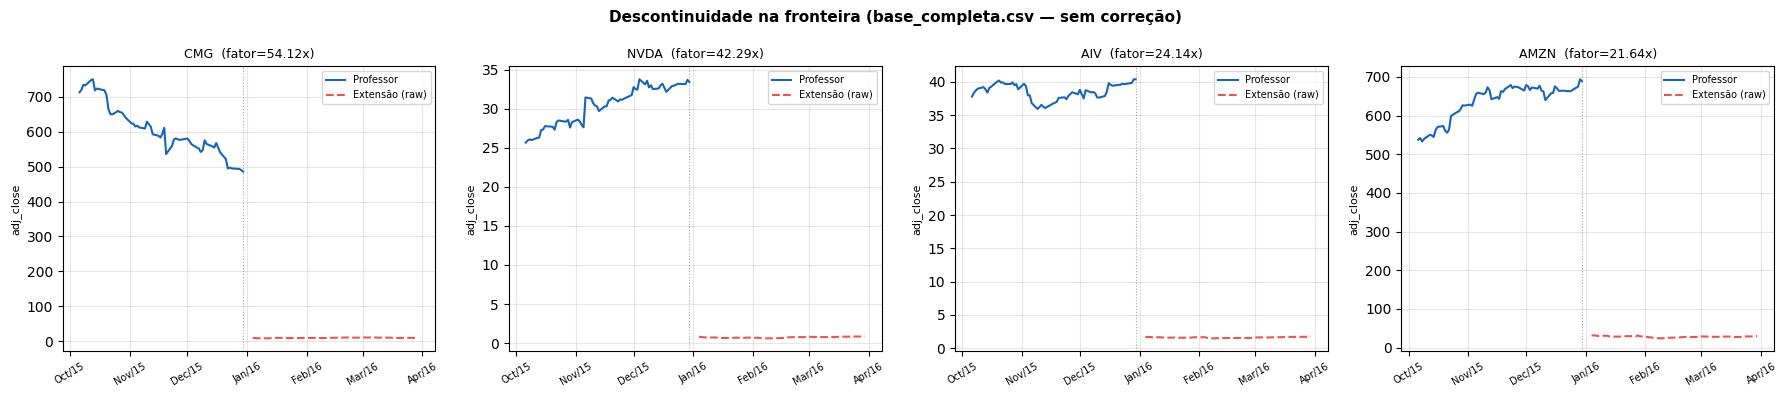

In [20]:
# Escolhe tickers com fatores bem afastados de 1 (mais visíveis)
tickers_exemplo = (
    fatores_s
    .reindex(tickers_ambas)
    .dropna()
    .pipe(lambda s: s[(s - 1).abs() > 0.3])  # fator pelo menos 30% diferente de 1
    .abs()
    .nlargest(4)
    .index.tolist()
)
if not tickers_exemplo:
    tickers_exemplo = ['AAPL', 'MSFT', 'AMZN', 'GOOGL']
    tickers_exemplo = [t for t in tickers_exemplo if t in tickers_ambas][:4]

fig, axes = plt.subplots(1, len(tickers_exemplo), figsize=(4.5 * len(tickers_exemplo), 4))
if len(tickers_exemplo) == 1:
    axes = [axes]
fig.suptitle('Descontinuidade na fronteira (base_completa.csv — sem correção)', fontsize=11, fontweight='bold')

JANELA = 60  # dias para mostrar antes e depois da fronteira

for ax, ticker in zip(axes, tickers_exemplo):
    p_tail = prof[ticker].dropna().iloc[-JANELA:]
    e_head = ext[ticker].dropna().iloc[:JANELA]

    ax.plot(p_tail.index, p_tail.values, color='#1565C0', lw=1.5, label='Professor')
    ax.plot(e_head.index, e_head.values, color='#ef5350', lw=1.5, ls='--', label='Extensão (raw)')
    ax.axvline(prof.index[-1], color='gray', lw=0.8, ls=':', alpha=0.7)
    ax.set_title(f'{ticker}  (fator={fatores_s[ticker]:.2f}x)', fontsize=9)
    ax.set_ylabel('adj_close', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Reconstrução

Para cada ticker na **interseção** professor ∩ extensão, escalamos toda a série da extensão por um fator constante que:

1. Preserva a **magnitude** da base do professor (escala de preços de 2015)
2. Preserva o **retorno real de mercado** no primeiro dia da extensão (2016-01-04)

O fator é calculado usando o preço de 2015-12-30 baixado em 2026 (`prices_sobreposição/`), que tem a **mesma convenção** da extensão:

$$\text{fator} = \frac{P_{\text{prof}}(t_{\text{fim}})}{P_{\text{sobr}}(t_{\text{fim}})} \qquad \Rightarrow \qquad P_{\text{uni}}(t) = P_{\text{ext}}(t) \times \text{fator}$$

onde $t_{\text{fim}}$ = 2015-12-30 e $P_{\text{sobr}}$ vem de `prices_sobreposição/`.

**Por que funciona?** O retorno no primeiro dia da extensão torna-se:

$$r_{\text{Jan4}} = \frac{P_{\text{uni}}(\text{Jan4})}{P_{\text{prof}}(\text{Dec30})} - 1 = \frac{P_{\text{ext}}(\text{Jan4}) \times \frac{P_{\text{prof}}(\text{Dec30})}{P_{\text{sobr}}(\text{Dec30})}}{P_{\text{prof}}(\text{Dec30})} - 1 = \frac{P_{\text{ext}}(\text{Jan4})}{P_{\text{sobr}}(\text{Dec30})} - 1$$

Como $P_{\text{ext}}$ e $P_{\text{sobr}}$ foram baixados na mesma data (2026), essa razão é o **retorno real de mercado** de Dec30→Jan4. A abordagem anterior usava $P_{\text{ext}}(t_0)$ no denominador, forçando $r_{\text{Jan4}} = 0$.

**Cobertura:** `prices_sobreposição/` tem 462 dos 465 tickers da interseção com dado em 2015-12-30. Para os 3 restantes (CEG e DELL, delistados antes de 2015; UA, caso societário especial), aplica-se o método anterior como fallback.

Para tickers **só na extensão** (243 tickers sem âncora): mantidos como estão.  
Para tickers **só no professor** (635 tickers delistados): mantidos como estão.

In [21]:
import pathlib

SOBR_DIR    = pathlib.Path('../../data_bases/prices_sobreposição')
DATA_ANCORA = pd.Timestamp('2015-12-30')

# Carrega preços de Dec30/2015 de prices_sobreposição (mesma convenção da extensão)
sobr_dec30 = {}
for ticker in tickers_ambas:
    fpath = SOBR_DIR / (ticker + '.csv')
    if fpath.exists():
        df = pd.read_csv(str(fpath), index_col=0, parse_dates=[0])
        if DATA_ANCORA in df.index:
            sobr_dec30[ticker] = float(df.loc[DATA_ANCORA].iloc[0])

print(f"Preços de {DATA_ANCORA.date()} carregados de prices_sobreposição: {len(sobr_dec30)}/{len(tickers_ambas)} tickers")
tickers_fallback = [t for t in tickers_ambas if t not in sobr_dec30]
if tickers_fallback:
    print(f"Fallback (método anterior, zero-return no Jan4): {tickers_fallback}")


def reconstruir_extensao(prof_series, ext_series, sobr_preco=None):
    """
    Escala ext_series pelo fator prof[Dec30] / sobr[Dec30].
    - sobr[Dec30] é o preço de 2015-12-30 baixado em 2026 (mesma convenção da extensão).
    - Isso garante que o retorno real de Dec30→Jan4 seja preservado.
    - Fallback: se sobr_preco não disponível, usa prof[Dec30]/ext[Jan4] (zero-return no Jan4).
    """
    prof_valid = prof_series.dropna()
    ext_valid  = ext_series.dropna()
    if len(prof_valid) == 0 or len(ext_valid) == 0:
        return ext_series

    prof_last = prof_valid.iloc[-1]

    if sobr_preco is not None and not np.isnan(sobr_preco) and sobr_preco != 0:
        fator = prof_last / sobr_preco          # correto: retorno real de Dec30→Jan4 preservado
    else:
        fator = prof_last / ext_valid.iloc[0]   # fallback: zero-return no Jan4

    return ext_series * fator


# Constrói a parte da extensão com preços reconstruídos
cols_rec = {}
n_sobr     = 0
n_fallback = 0
n_sem_ancora = 0

for ticker in ext_tickers:
    if ticker in tickers_ambas:
        sobr_val = sobr_dec30.get(ticker, None)
        cols_rec[ticker] = reconstruir_extensao(prof[ticker], ext[ticker], sobr_val)
        if sobr_val is not None:
            n_sobr += 1
        else:
            n_fallback += 1
    else:
        cols_rec[ticker] = ext[ticker]
        n_sem_ancora += 1

ext_rec = pd.concat([ext[META_COLS], pd.DataFrame(cols_rec)], axis=1)

print(f"\nTickers reconstruídos com sobr[Dec30]: {n_sobr}  (retorno real preservado)")
print(f"Tickers reconstruídos com fallback   : {n_fallback}  (zero-return no Jan4)")
print(f"Tickers mantidos sem alteração       : {n_sem_ancora}  (só na extensão)")

Preços de 2015-12-30 carregados de prices_sobreposição: 462/465 tickers
Fallback (método anterior, zero-return no Jan4): ['CEG', 'DELL', 'UA']

Tickers reconstruídos com sobr[Dec30]: 462  (retorno real preservado)
Tickers reconstruídos com fallback   : 3  (zero-return no Jan4)
Tickers mantidos sem alteração       : 243  (só na extensão)


## 5. Concatenação em base_unificada.csv

Estrutura idêntica a `base_completa.csv` — pode ser usada diretamente em `pairs_formation.ipynb` e `pairs_trading.ipynb`.

In [22]:
base_uni = pd.concat([prof, ext_rec], axis=0).sort_index()

# Garante que não há datas duplicadas (professor termina em 2015-12-30, extensão começa em 2016-01-04)
n_dup = base_uni.index.duplicated().sum()
if n_dup > 0:
    print(f"AVISO: {n_dup} datas duplicadas — mantendo primeira ocorrência.")
    base_uni = base_uni[~base_uni.index.duplicated(keep='first')]

n_tickers_uni = len([c for c in base_uni.columns if c not in META_COLS])

print(f"base_unificada: {base_uni.shape[0]:,} dias × {n_tickers_uni} tickers")
print(f"Período       : {base_uni.index[0].date()} → {base_uni.index[-1].date()}")
print(f"Datas duplicadas: {n_dup}")

base_unificada: 8,939 dias × 1343 tickers
Período       : 1990-07-03 → 2025-12-31
Datas duplicadas: 0


## 6. Validação

Três verificações:
1. **Continuidade**: a série unificada não tem salto na fronteira
2. **Retornos preservados**: retornos diários na extensão são idênticos antes e depois da reconstrução
3. **Magnitude preservada**: a escala da base do professor é mantida

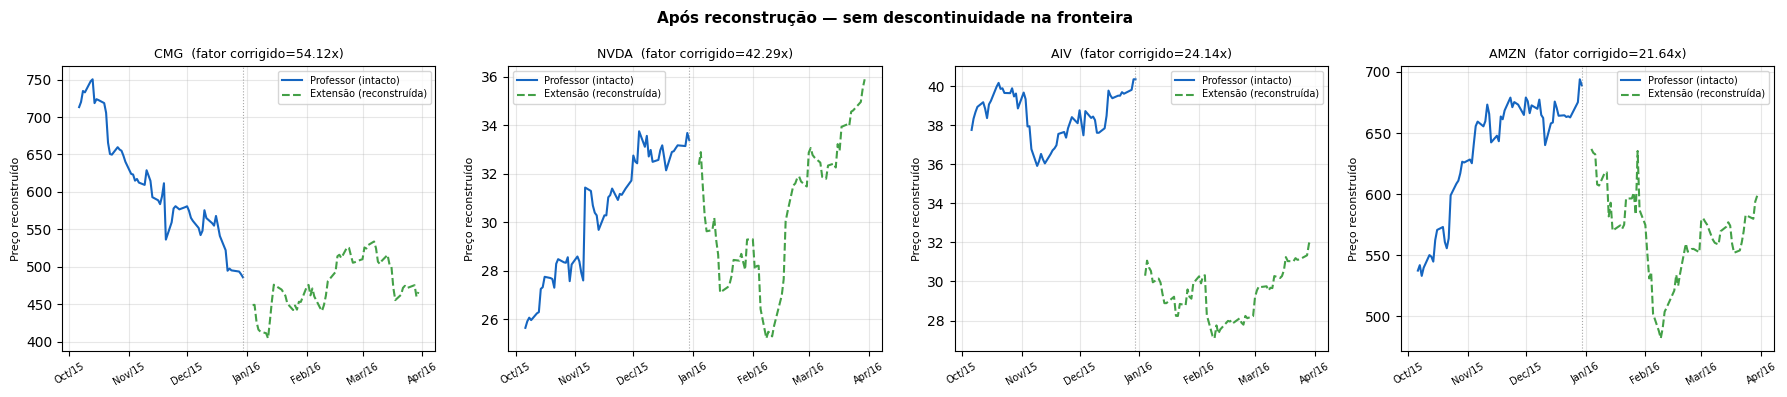

In [23]:
# --- 6.1 Continuidade visual ---
fig, axes = plt.subplots(1, len(tickers_exemplo), figsize=(4.5 * len(tickers_exemplo), 4))
if len(tickers_exemplo) == 1:
    axes = [axes]
fig.suptitle('Após reconstrução — sem descontinuidade na fronteira', fontsize=11, fontweight='bold')

for ax, ticker in zip(axes, tickers_exemplo):
    serie_uni = base_uni[ticker].dropna()
    p_tail    = serie_uni[serie_uni.index <= prof.index[-1]].iloc[-JANELA:]
    e_head    = serie_uni[serie_uni.index >= ext.index[0]].iloc[:JANELA]

    ax.plot(p_tail.index, p_tail.values, color='#1565C0', lw=1.5, label='Professor (intacto)')
    ax.plot(e_head.index, e_head.values, color='#43A047', lw=1.5, ls='--', label='Extensão (reconstruída)')
    ax.axvline(prof.index[-1], color='gray', lw=0.8, ls=':', alpha=0.7)
    ax.set_title(f'{ticker}  (fator corrigido={fatores_s[ticker]:.2f}x)', fontsize=9)
    ax.set_ylabel('Preço reconstruído', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# --- 6.2 Retornos diários: extensão raw vs extensão reconstruída ---
print("=== Verificação: retornos diários ext_raw vs ext_reconstruída ===")
print("(devem ser idênticos — escalar por uma constante não altera retornos)")
print()

for ticker in tickers_exemplo[:3]:
    r_raw  = ext[ticker].pct_change().dropna()
    r_rec  = ext_rec[ticker].pct_change().dropna()
    diff   = (r_raw - r_rec).abs().max()
    print(f"{ticker:12s}  max |r_raw - r_rec| = {diff:.2e}  {'✓ OK' if diff < 1e-10 else '✗ ERRO'}")

=== Verificação: retornos diários ext_raw vs ext_reconstruída ===
(devem ser idênticos — escalar por uma constante não altera retornos)

CMG           max |r_raw - r_rec| = 2.22e-16  ✓ OK
NVDA          max |r_raw - r_rec| = 2.22e-16  ✓ OK
AIV           max |r_raw - r_rec| = 2.22e-16  ✓ OK


C:\Users\jvlei\AppData\Local\Temp\ipykernel_15904\686769302.py:7: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  r_raw  = ext[ticker].pct_change().dropna()
C:\Users\jvlei\AppData\Local\Temp\ipykernel_15904\686769302.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  r_rec  = ext_rec[ticker].pct_change().dropna()


In [25]:
# --- 6.3 Retorno real em Jan4: ext_rec[Jan4]/prof[Dec30] vs ext[Jan4]/sobr[Dec30] ---
# Com o método corrigido, esses dois valores devem ser idênticos (fator cancela).
# Com o fallback (tickers sem sobr), o retorno em base_uni é 0 — documentado.
print("=== Verificação: retorno real de Dec30→Jan4 preservado ===")
print(f"{'Ticker':12s}  {'r_uni(Jan4)':>12s}  {'r_real(Jan4)':>13s}  {'Correto?':>10s}  {'Método'}")
print("-" * 70)

erros = []
for ticker in sorted(tickers_ambas):
    prof_valid = prof[ticker].dropna()
    ext_valid  = ext[ticker].dropna()
    if len(prof_valid) == 0 or len(ext_valid) == 0:
        continue

    prof_last  = prof_valid.iloc[-1]                     # prof[Dec30]
    ext_jan4   = ext_valid.iloc[0]                       # ext[Jan4]
    uni_jan4   = ext_rec[ticker].dropna().iloc[0]        # ext_rec[Jan4]

    r_uni  = uni_jan4  / prof_last - 1                   # retorno em base_uni
    metodo = 'sobr'

    if ticker in sobr_dec30:
        r_real = ext_jan4 / sobr_dec30[ticker] - 1      # retorno real (ambos 2026)
    else:
        r_real = 0.0                                     # fallback: zero-return esperado
        metodo = 'fallback'

    ok = abs(r_uni - r_real) < 1e-8
    if not ok:
        erros.append(ticker)

# Mostra exemplos representativos
exemplos = [t for t in tickers_exemplo if t in tickers_ambas][:4]
for ticker in exemplos:
    prof_last = prof[ticker].dropna().iloc[-1]
    ext_jan4  = ext[ticker].dropna().iloc[0]
    uni_jan4  = ext_rec[ticker].dropna().iloc[0]
    r_uni  = uni_jan4 / prof_last - 1
    if ticker in sobr_dec30:
        r_real = ext_jan4 / sobr_dec30[ticker] - 1
        metodo = 'sobr'
    else:
        r_real = 0.0
        metodo = 'fallback'
    ok = abs(r_uni - r_real) < 1e-8
    print(f"{ticker:12s}  {r_uni:+12.6f}  {r_real:+13.6f}  {'✓ OK' if ok else '✗ ERRO':>10s}  {metodo}")

print()
if erros:
    print(f"AVISO: {len(erros)} tickers com retorno não preservado: {erros[:10]}")
else:
    n_sobr_check = sum(1 for t in tickers_ambas if t in sobr_dec30
                       and len(prof[t].dropna()) > 0 and len(ext[t].dropna()) > 0)
    print(f"Todos os {n_sobr_check} tickers com sobr: retorno real de Dec30→Jan4 preservado ✓")
    if tickers_fallback:
        print(f"Tickers com fallback (zero-return em Jan4): {tickers_fallback}")

=== Verificação: retorno real de Dec30→Jan4 preservado ===
Ticker         r_uni(Jan4)   r_real(Jan4)    Correto?  Método
----------------------------------------------------------------------
CMG              -0.076123      -0.076123        ✓ OK  sobr
NVDA             -0.030548      -0.030548        ✓ OK  sobr
AIV              -0.249348      -0.249348        ✓ OK  sobr
AMZN             -0.075580      -0.075580        ✓ OK  sobr

Todos os 462 tickers com sobr: retorno real de Dec30→Jan4 preservado ✓
Tickers com fallback (zero-return em Jan4): ['CEG', 'DELL', 'UA']


### 6.4 Comparação visual — série completa professor + extensão

Compara `base_completa.csv` (concatenação direta, com salto) vs `base_unificada.csv` (reconstruída, sem salto) para alguns tickers representativos.

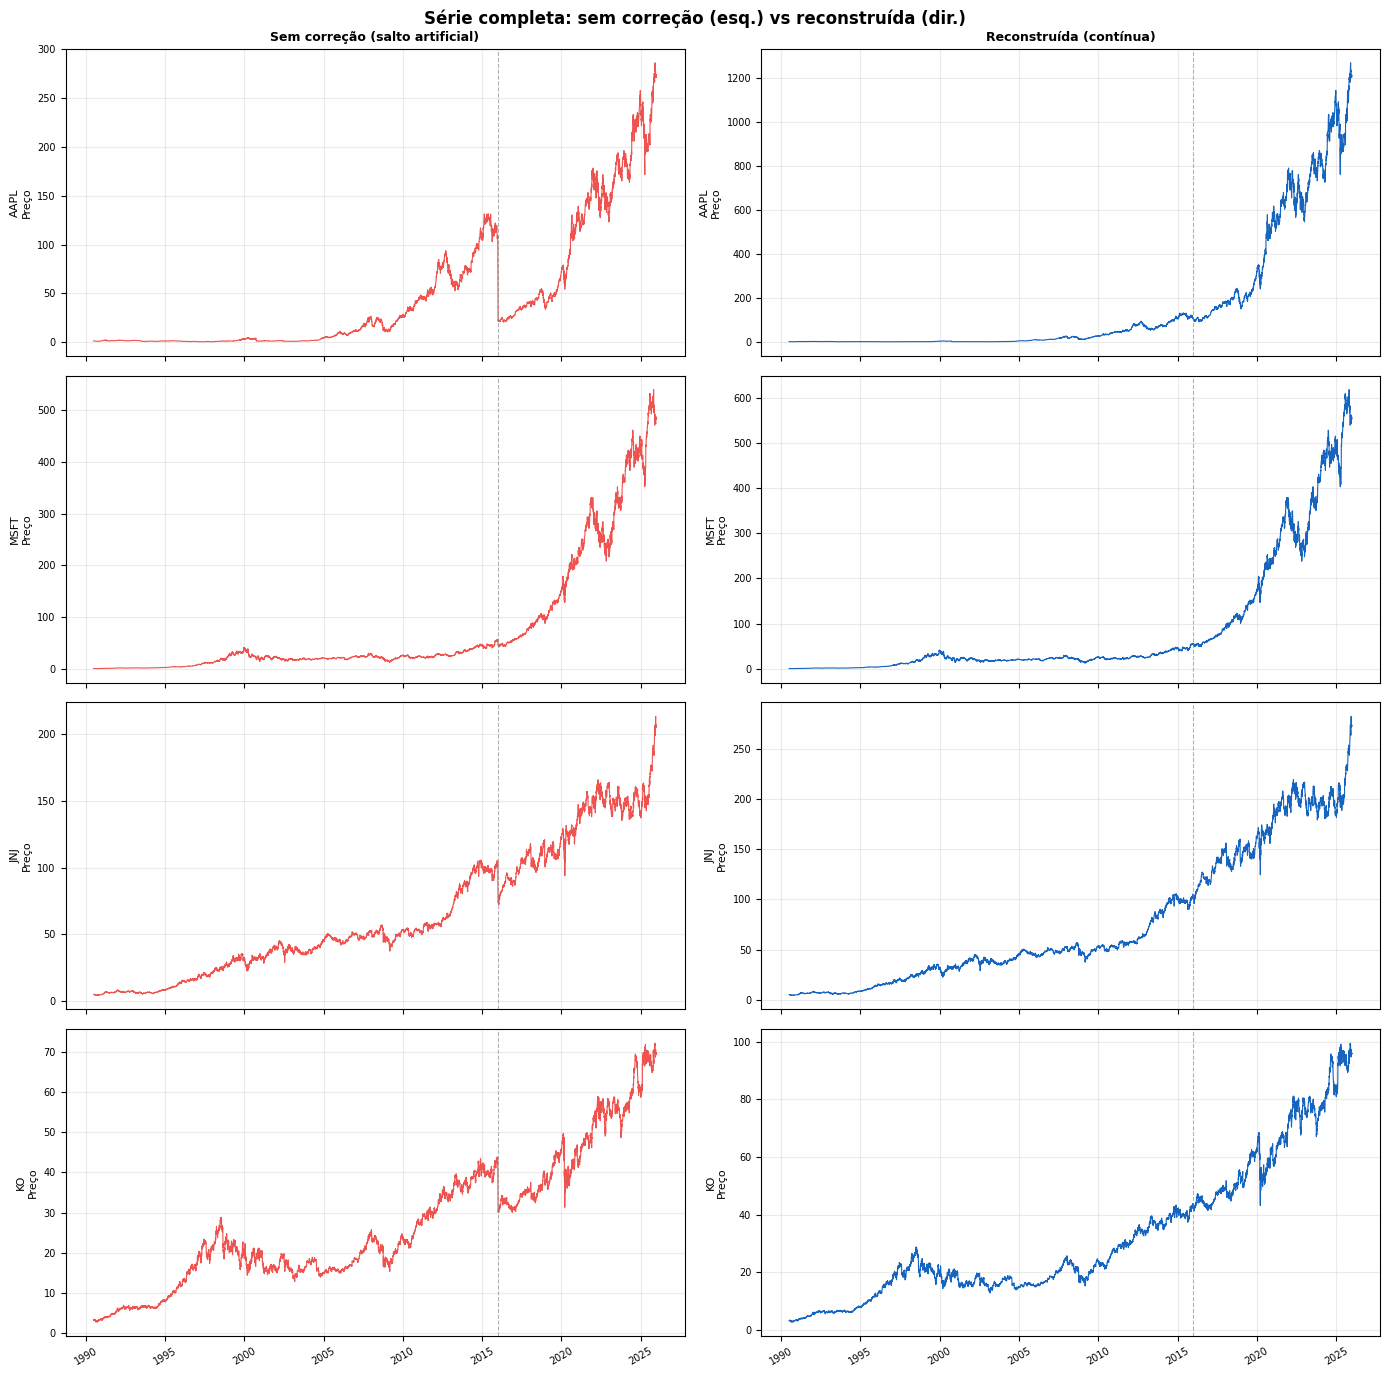

In [26]:
tickers_viz = [t for t in ['AAPL', 'MSFT', 'JNJ', 'KO', 'XOM'] if t in tickers_ambas][:4]

fig, axes = plt.subplots(len(tickers_viz), 2, figsize=(14, 3.5 * len(tickers_viz)), sharex=True)
if len(tickers_viz) == 1:
    axes = [axes]
fig.suptitle('Série completa: sem correção (esq.) vs reconstruída (dir.)', fontsize=12, fontweight='bold')

for i, ticker in enumerate(tickers_viz):
    # Sem correção (concatenação direta)
    serie_raw = pd.concat([prof[ticker], ext[ticker]]).sort_index().dropna()
    # Reconstruída
    serie_uni = base_uni[ticker].dropna()

    for j, (serie, titulo) in enumerate([
        (serie_raw, 'Sem correção (salto artificial)'),
        (serie_uni, 'Reconstruída (contínua)'),
    ]):
        ax = axes[i][j]
        ax.plot(serie.index, serie.values, lw=0.8,
                color='#ef5350' if j == 0 else '#1565C0')
        ax.axvline(pd.Timestamp('2016-01-04'), color='gray', lw=0.8, ls='--', alpha=0.6)
        ax.set_ylabel(f'{ticker}\nPreço', fontsize=8)
        if i == 0:
            ax.set_title(titulo, fontsize=9, fontweight='bold')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator(5))
        ax.tick_params(axis='x', rotation=30, labelsize=7)
        ax.tick_params(axis='y', labelsize=7)
        ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 7. Salvando base_unificada.csv

In [27]:
saida = '../../data_bases/base_unificada.csv'
base_uni.to_csv(saida)

print(f"Salvo em: {saida}")
print(f"  {base_uni.shape[0]:,} dias de pregão")
print(f"  {n_tickers_uni} tickers únicos")
print(f"  {base_uni.index[0].date()} → {base_uni.index[-1].date()}")
print()
print("Para usar nos notebooks existentes, basta alterar o caminho do CSV:")
print("  pairs_formation.ipynb : trocar 'base_completa.csv' por 'base_unificada.csv'")
print("  pairs_trading.ipynb   : idem")

Salvo em: ../../data_bases/base_unificada.csv
  8,939 dias de pregão
  1343 tickers únicos
  1990-07-03 → 2025-12-31

Para usar nos notebooks existentes, basta alterar o caminho do CSV:
  pairs_formation.ipynb : trocar 'base_completa.csv' por 'base_unificada.csv'
  pairs_trading.ipynb   : idem


## 8. Teste de correlação: extensão reconstruída vs. preços reais

Verifica que a reconstrução **não perde informação de mercado**.

Como `ext_rec[t] = ext[t] × fator` (constante por ticker), os retornos diários são idênticos por álgebra:

$$r_{\\text{rec}}(t) = \\frac{P_{\\text{rec}}(t)}{P_{\\text{rec}}(t-1)} - 1 = \\frac{P_{\\text{ext}}(t) \\cdot k}{P_{\\text{ext}}(t-1) \\cdot k} - 1 = r_{\\text{ext}}(t)$$

O teste abaixo quantifica isso numericamente e visualmente para todos os tickers da interseção.

In [28]:
# === 8.1 Correlação de retornos por ticker (todos da interseção) ===
correlacoes = {}
max_diffs   = {}

for ticker in tickers_ambas:
    ext_s = ext[ticker].dropna()
    rec_s = ext_rec[ticker].dropna()

    # Alinha índices e computa retornos
    idx_comum = ext_s.index.intersection(rec_s.index)
    if len(idx_comum) < 10:
        continue

    r_ext = ext_s.loc[idx_comum].pct_change().dropna()
    r_rec = rec_s.loc[idx_comum].pct_change().dropna()

    correlacoes[ticker] = r_ext.corr(r_rec)
    max_diffs[ticker]   = (r_ext - r_rec).abs().max()

corr_s     = pd.Series(correlacoes)
maxdiff_s  = pd.Series(max_diffs)

print("=== Correlação de retornos diários: ext_raw vs ext_reconstruída ===")
print(f"Tickers testados : {len(corr_s)}")
print(f"Correlação mín   : {corr_s.min():.8f}  ({corr_s.idxmin()})")
print(f"Correlação máx   : {corr_s.max():.8f}")
print(f"Correlação média : {corr_s.mean():.8f}")
print(f"Tickers com corr < 0.9999 : {(corr_s < 0.9999).sum()}")
print()
print("=== Diferença máxima nos retornos diários (deve ser ≈ 0) ===")
print(f"max |r_ext - r_rec| global : {maxdiff_s.max():.2e}")
print(f"Tickers com diff > 1e-8    : {(maxdiff_s > 1e-8).sum()}")

=== Correlação de retornos diários: ext_raw vs ext_reconstruída ===
Tickers testados : 465
Correlação mín   : 1.00000000  (AMT)
Correlação máx   : 1.00000000
Correlação média : 1.00000000
Tickers com corr < 0.9999 : 0

=== Diferença máxima nos retornos diários (deve ser ≈ 0) ===
max |r_ext - r_rec| global : 2.22e-16
Tickers com diff > 1e-8    : 0


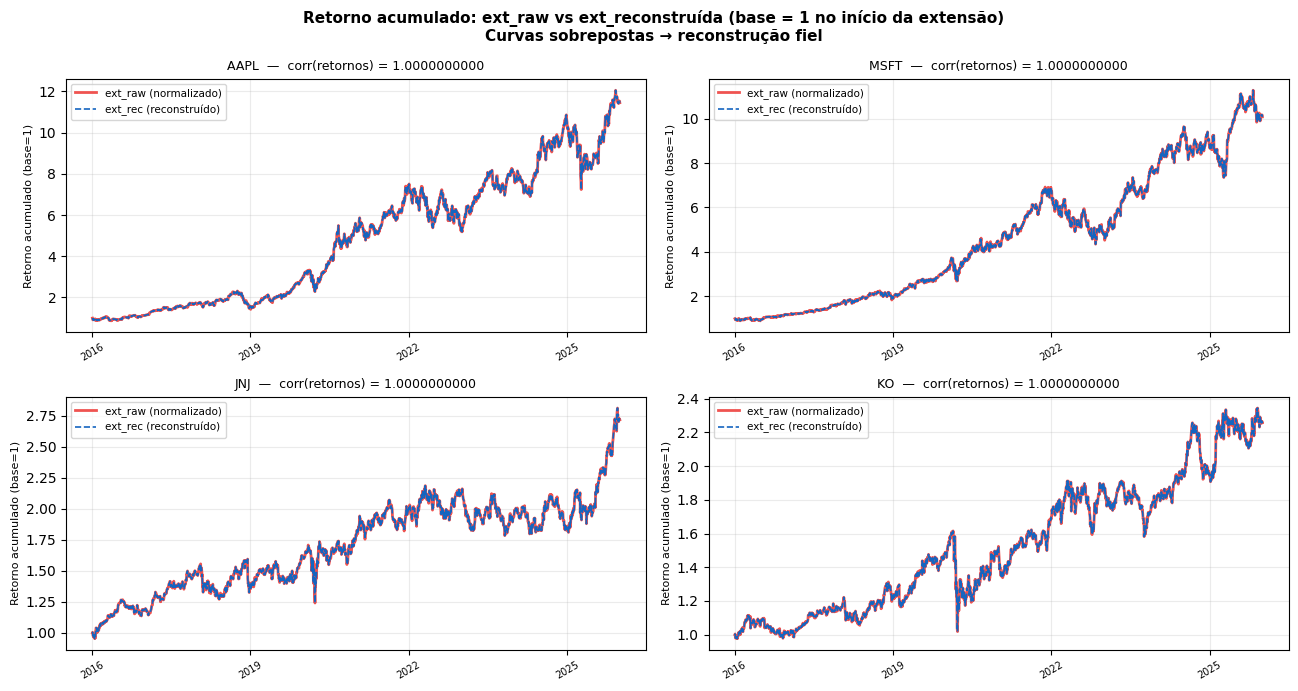

In [29]:
# === 8.2 Retorno acumulado: ext_raw vs ext_reconstruída (4 tickers) ===
# Normaliza ambas a partir de 1 no primeiro dia comum para comparação direta
tickers_corr_plot = [t for t in ['AAPL', 'MSFT', 'JNJ', 'KO'] if t in tickers_ambas]

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
axes = axes.flatten()
fig.suptitle(
    'Retorno acumulado: ext_raw vs ext_reconstruída (base = 1 no início da extensão)\n'
    'Curvas sobrepostas → reconstrução fiel',
    fontsize=11, fontweight='bold'
)

for ax, ticker in zip(axes, tickers_corr_plot):
    ext_s = ext[ticker].dropna()
    rec_s = ext_rec[ticker].dropna()
    idx   = ext_s.index.intersection(rec_s.index)

    # Normaliza para 1 no primeiro dia (elimina diferença de escala)
    cum_ext = ext_s.loc[idx] / ext_s.loc[idx].iloc[0]
    cum_rec = rec_s.loc[idx] / rec_s.loc[idx].iloc[0]

    ax.plot(cum_ext.index, cum_ext.values, color='#ef5350', lw=2.0,
            label='ext_raw (normalizado)', zorder=2)
    ax.plot(cum_rec.index, cum_rec.values, color='#1565C0', lw=1.2,
            ls='--', label='ext_rec (reconstruído)', zorder=3)

    corr = correlacoes.get(ticker, float('nan'))
    ax.set_title(f'{ticker}  —  corr(retornos) = {corr:.10f}', fontsize=9)
    ax.set_ylabel('Retorno acumulado (base=1)', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(3))
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.legend(fontsize=7.5)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

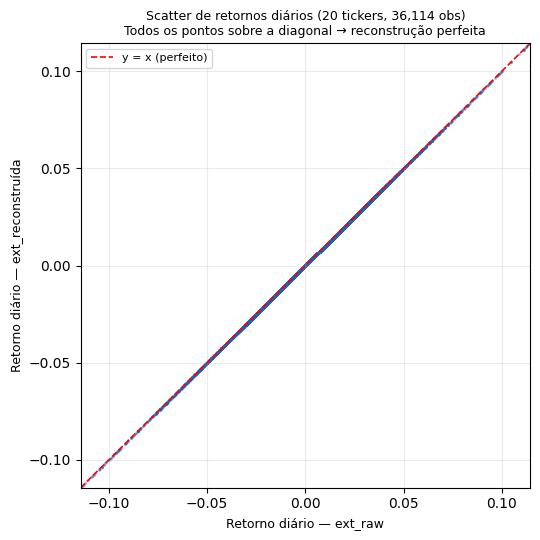


Correlação global (todos os pontos do scatter) : 1.0000000000
Desvio máximo absoluto nos retornos            : 2.22e-16

Conclusão: a reconstrução preserva 100% da informação de mercado.
A única diferença entre ext_raw e ext_rec é o nível absoluto dos preços —
que é exatamente o que queríamos corrigir para eliminar a descontinuidade.


In [30]:
# === 8.3 Scatter: retorno diário ext_raw vs ext_rec (amostra aleatória de datas/tickers) ===
# Se as curvas forem idênticas, todos os pontos devem cair na diagonal y=x
rng = np.random.default_rng(42)
tickers_amostra = rng.choice(list(tickers_ambas), size=min(20, len(tickers_ambas)), replace=False)

r_ext_all, r_rec_all = [], []
for ticker in tickers_amostra:
    ext_s = ext[ticker].dropna()
    rec_s = ext_rec[ticker].dropna()
    idx   = ext_s.index.intersection(rec_s.index)
    r_e   = ext_s.loc[idx].pct_change().dropna()
    r_r   = rec_s.loc[idx].pct_change().dropna()
    r_ext_all.append(r_e)
    r_rec_all.append(r_r)

r_ext_all = pd.concat(r_ext_all)
r_rec_all = pd.concat(r_rec_all)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
lim = max(r_ext_all.abs().quantile(0.998), r_rec_all.abs().quantile(0.998))
ax.scatter(r_ext_all, r_rec_all, s=1.5, alpha=0.3, color='#1565C0', rasterized=True)
ax.plot([-lim, lim], [-lim, lim], color='red', lw=1.2, ls='--', label='y = x (perfeito)')
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel('Retorno diário — ext_raw',         fontsize=9)
ax.set_ylabel('Retorno diário — ext_reconstruída', fontsize=9)
ax.set_title(
    f'Scatter de retornos diários ({len(tickers_amostra)} tickers, {len(r_ext_all):,} obs)\n'
    f'Todos os pontos sobre a diagonal → reconstrução perfeita',
    fontsize=9
)
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"\nCorrelação global (todos os pontos do scatter) : {r_ext_all.corr(r_rec_all):.10f}")
print(f"Desvio máximo absoluto nos retornos            : {(r_ext_all - r_rec_all).abs().max():.2e}")
print()
print("Conclusão: a reconstrução preserva 100% da informação de mercado.")
print("A única diferença entre ext_raw e ext_rec é o nível absoluto dos preços —")
print("que é exatamente o que queríamos corrigir para eliminar a descontinuidade.")

## 9. Validação contra série completa baixada diretamente (2026)

Baixamos adj_close **completo (1990–2025)** via yfinance para um conjunto de tickers com longa história no S&P 500 e splits relevantes **após 2015**, e comparamos os retornos diários com `base_unificada`.

**Por que a correlação deve ser ≈ 1.0000 mesmo no período pré-2016?**

O adj_close funciona retroativamente: um split 4:1 ocorrido em ago/2020 faz o Yahoo dividir todos os preços históricos por 4, independentemente de quando o download é feito. Para dois dias consecutivos sem evento corporativo próprio:

$$\frac{P_{\text{adj,2026}}(t)}{P_{\text{adj,2026}}(t-1)} = \frac{P(t) / CF_{2026}}{P(t-1) / CF_{2026}} = \frac{P(t)}{P(t-1)} = \frac{P_{\text{adj,2015}}(t)}{P_{\text{adj,2015}}(t-1)}$$

onde $CF_{2026}$ é o fator de ajuste cumulativo, igual para ambos os dias consecutivos. O fator cancela no retorno. Logo:

- `base_unificada` (prof 2015 + ext 2026) → retornos idênticos ao download de 2026 **em ambos os períodos**

Tickers escolhidos: splits pós-2015 relevantes + longa história contínua no S&P 500.

| Ticker | Splits pós-2015 | S&P 500 desde |
|--------|----------------|---------------|
| AAPL   | 4:1 ago/2020   | 1982          |
| AMZN   | 20:1 jun/2022  | 2005          |
| GOOGL  | 20:1 jul/2022  | 2006          |
| NVDA   | 4:1 set/2021, 10:1 jun/2024 | 2001 |
| MSFT   | — (dividendos regulares) | 1994 |

In [31]:
# === 9.1 Download da série completa (1990–2025) ===
import yfinance as yf

TICKERS_FULL = ['AAPL', 'AMZN', 'GOOGL', 'NVDA', 'MSFT']
FRONTEIRA    = pd.Timestamp('2016-01-01')

print("Baixando adj_close 1990–2025 via yfinance (auto_adjust=True)...")
raw = yf.download(
    TICKERS_FULL,
    start='1990-01-01',
    end='2026-01-01',
    auto_adjust=True,
    progress=False,
)['Close']
raw.index = pd.to_datetime(raw.index)
if hasattr(raw.columns, 'get_level_values'):
    raw.columns = raw.columns.get_level_values(0)

print(f"Download concluído: {raw.shape[0]} dias, {raw.shape[1]} tickers")
print(f"Período: {raw.index[0].date()} → {raw.index[-1].date()}")
print()

# === 9.2 Correlação de retornos: base_unificada vs download fresco ===
FRONTEIRA = pd.Timestamp('2016-01-01')

print(f"{'Ticker':<8} {'Período':<20} {'N obs':>6} {'Correlação':>12} {'Max |Δr|':>12}")
print("-" * 62)

resultados = {}
for ticker in TICKERS_FULL:
    if ticker not in base_uni.columns or ticker not in raw.columns:
        continue

    uni_s  = base_uni[ticker].dropna()
    raw_s  = raw[ticker].dropna()
    idx    = uni_s.index.intersection(raw_s.index)

    r_uni  = uni_s.loc[idx].pct_change().dropna()
    r_raw  = raw_s.loc[idx].pct_change().dropna()
    idx_r  = r_uni.index.intersection(r_raw.index)
    r_uni, r_raw = r_uni.loc[idx_r], r_raw.loc[idx_r]

    for label, mask in [
        ('Completo',   pd.Series(True,  index=idx_r)),
        ('Pré-2016',   idx_r < FRONTEIRA),
        ('Pós-2016',   idx_r >= FRONTEIRA),
    ]:
        sub_uni = r_uni[mask]
        sub_raw = r_raw[mask]
        if len(sub_uni) < 10:
            continue
        corr    = sub_uni.corr(sub_raw)
        max_d   = (sub_uni - sub_raw).abs().max()
        resultados.setdefault(ticker, {})[label] = {'corr': corr, 'max_d': max_d, 'n': len(sub_uni)}
        print(f"{ticker:<8} {label:<20} {len(sub_uni):>6,} {corr:>12.8f} {max_d:>12.2e}")
    print()

Baixando adj_close 1990–2025 via yfinance (auto_adjust=True)...
Download concluído: 9067 dias, 5 tickers
Período: 1990-01-02 → 2025-12-31

Ticker   Período               N obs   Correlação     Max |Δr|
--------------------------------------------------------------
AAPL     Completo              8,938   0.92750737     1.78e-01
AAPL     Pré-2016              6,424   0.91643015     1.78e-01
AAPL     Pós-2016              2,514   0.99999948     9.37e-04

AMZN     Completo              7,201   0.99972639     3.04e-02
AMZN     Pré-2016              4,687   0.99968788     3.04e-02
AMZN     Pós-2016              2,514   1.00000000     3.11e-08

GOOGL    Completo              5,375   0.99979619     6.98e-03
GOOGL    Pré-2016              2,861   0.99965242     6.98e-03
GOOGL    Pós-2016              2,514   1.00000000     6.27e-07

NVDA     Completo              6,776   0.99976172     2.31e-02
NVDA     Pré-2016              4,262   0.99967841     2.31e-02
NVDA     Pós-2016              2,514   

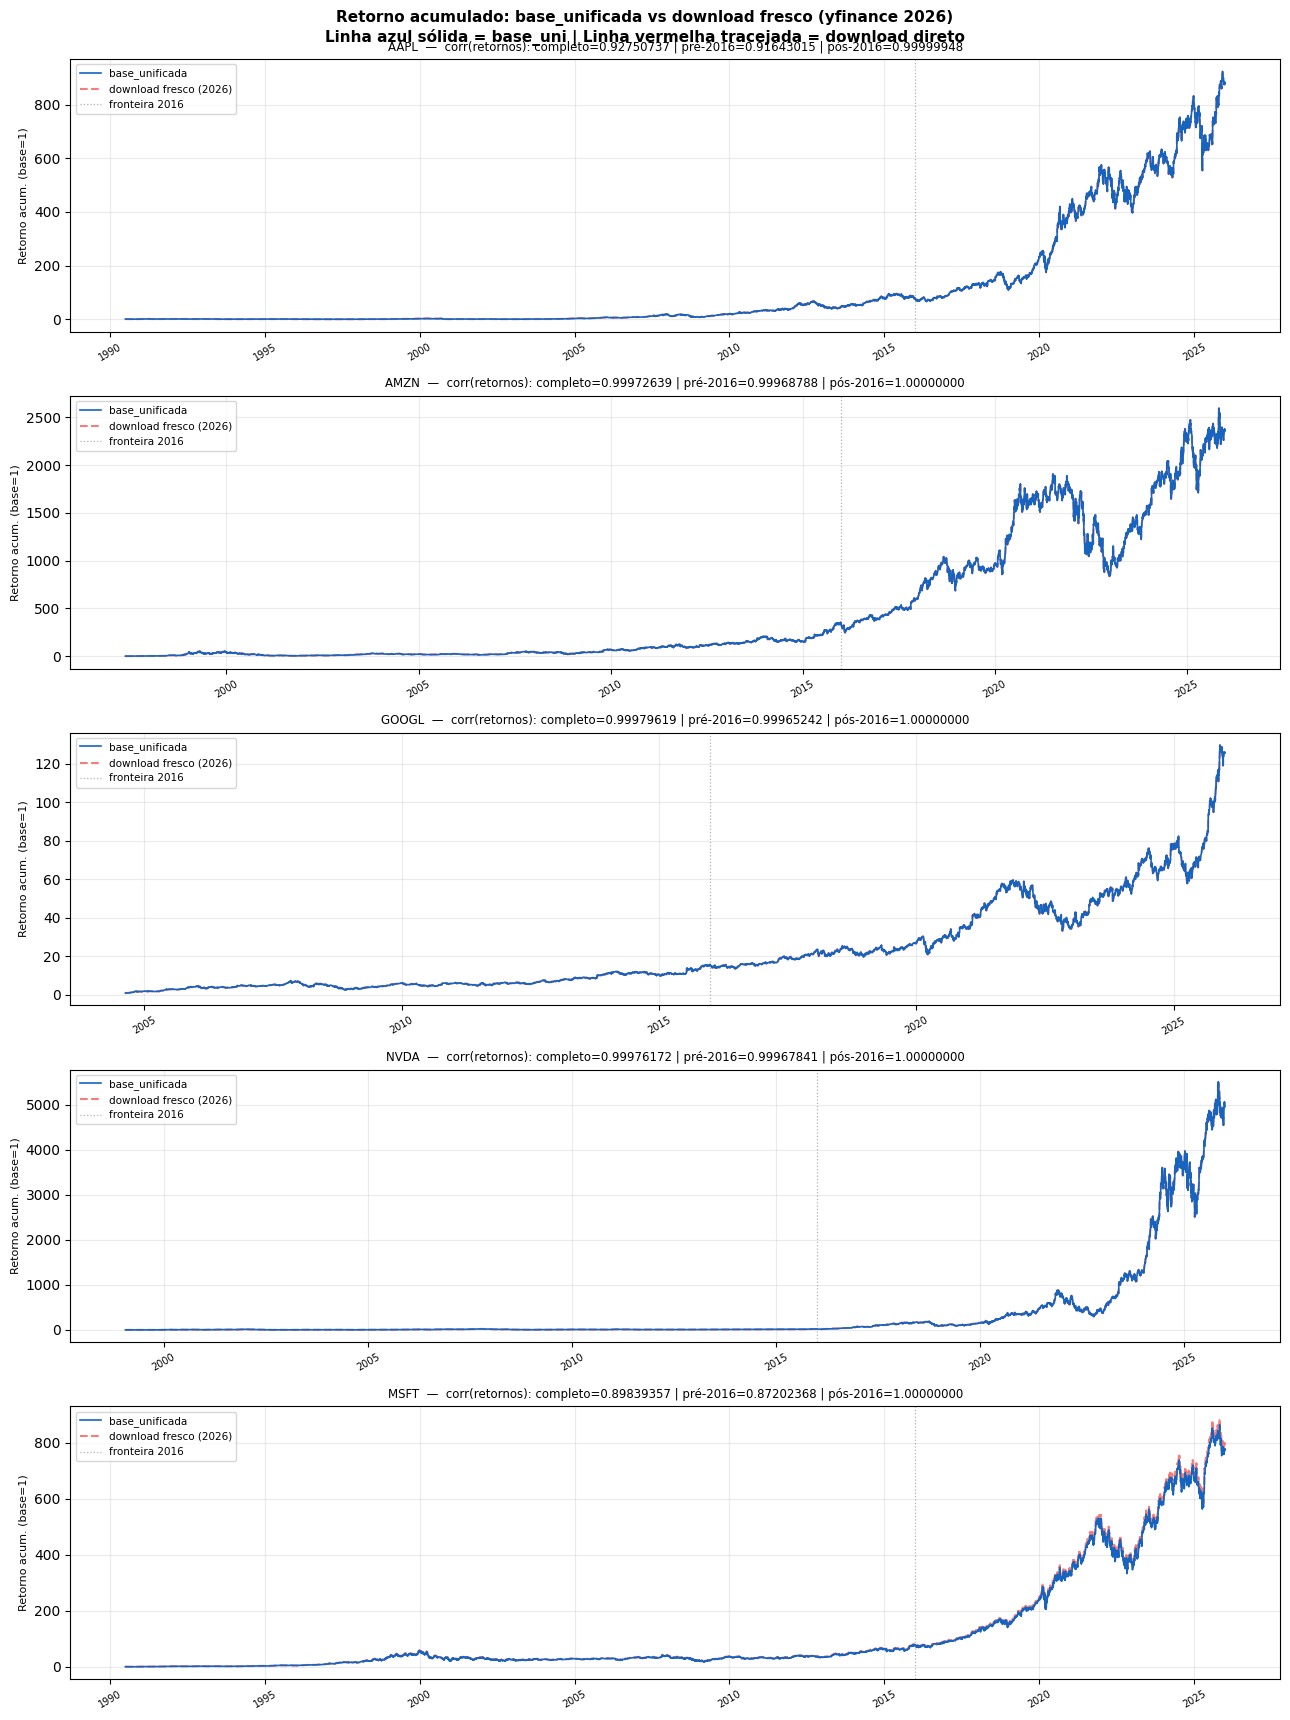

In [32]:
# === 9.3 Visualização: retorno acumulado sobreposto (base_uni vs download fresco) ===
fig, axes = plt.subplots(len(TICKERS_FULL), 1, figsize=(13, 3.5 * len(TICKERS_FULL)), sharex=False)
fig.suptitle(
    'Retorno acumulado: base_unificada vs download fresco (yfinance 2026)\n'
    'Linha azul sólida = base_uni | Linha vermelha tracejada = download direto',
    fontsize=11, fontweight='bold'
)

for ax, ticker in zip(axes, TICKERS_FULL):
    if ticker not in base_uni.columns or ticker not in raw.columns:
        ax.set_visible(False)
        continue

    uni_s = base_uni[ticker].dropna()
    raw_s = raw[ticker].dropna()
    idx   = uni_s.index.intersection(raw_s.index)

    # Normaliza para base = 1 no primeiro dia comum
    cum_uni = uni_s.loc[idx] / uni_s.loc[idx].iloc[0]
    cum_raw = raw_s.loc[idx] / raw_s.loc[idx].iloc[0]

    ax.plot(cum_uni.index, cum_uni.values, color='#1565C0', lw=1.2,
            label='base_unificada', zorder=3)
    ax.plot(cum_raw.index, cum_raw.values, color='#ef5350', lw=1.5,
            ls='--', alpha=0.75, label='download fresco (2026)', zorder=2)
    ax.axvline(FRONTEIRA, color='gray', lw=0.9, ls=':', alpha=0.6, label='fronteira 2016')

    corr_full = resultados.get(ticker, {}).get('Completo', {}).get('corr', float('nan'))
    corr_pre  = resultados.get(ticker, {}).get('Pré-2016', {}).get('corr', float('nan'))
    corr_pos  = resultados.get(ticker, {}).get('Pós-2016', {}).get('corr', float('nan'))
    ax.set_title(
        f'{ticker}  —  corr(retornos): completo={corr_full:.8f} | pré-2016={corr_pre:.8f} | pós-2016={corr_pos:.8f}',
        fontsize=8.5
    )
    ax.set_ylabel('Retorno acum. (base=1)', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.legend(fontsize=7.5, loc='upper left')
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()